# Effec Revenue Intelligence - Model Evaluation

Compares a seasonal-naive baseline against two candidate regression models trained on lag/rolling/calendar features, using a chronological train/test split.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
import numpy as np
from src.ingestion import load_transactions, prepare_daily_revenue
from src.forecasting import compare_models
%matplotlib inline

## Load daily revenue and run comparison

In [2]:
transactions = load_transactions(data_dir='../data/input')
daily = prepare_daily_revenue(transactions)
comparison = compare_models(daily)
comparison['best_model_name']

'linear_regression'

In [3]:
for name, res in comparison['results'].items():
    print(name, res['metrics'])

seasonal_naive_baseline {'mae': 5406.369711267606, 'rmse': 8572.614698034478, 'mape': 77.23884238046519}
linear_regression {'mae': 4608.430099334683, 'rmse': 6311.451871329779, 'mape': 62.7469477561144}
gradient_boosting {'mae': 6198.6051813282165, 'rmse': 10192.661288564152, 'mape': 85.2617577798629}


## Baseline vs candidate model comparison chart

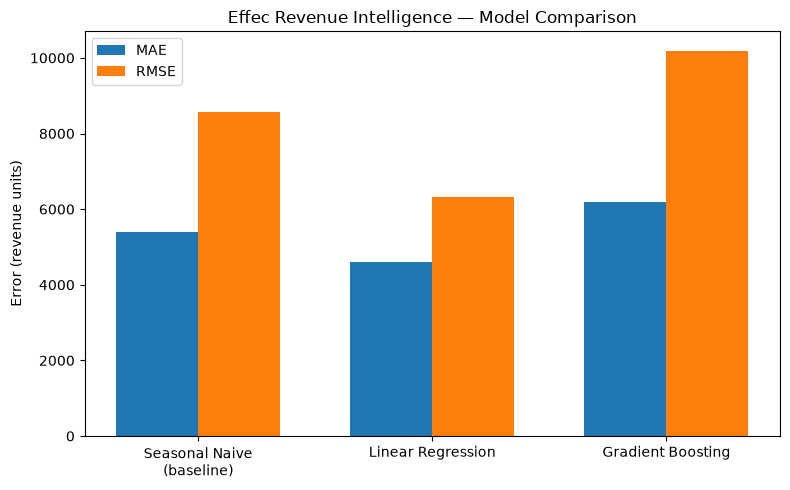

In [4]:
names = list(comparison['results'].keys())
labels = ['Seasonal Naive\n(baseline)', 'Linear Regression', 'Gradient Boosting']
mae = [comparison['results'][n]['metrics']['mae'] for n in names]
rmse = [comparison['results'][n]['metrics']['rmse'] for n in names]
x = np.arange(len(labels)); width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, mae, width, label='MAE')
ax.bar(x + width/2, rmse, width, label='RMSE')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Error (revenue units)')
ax.set_title('Effec Revenue Intelligence \u2014 Model Comparison')
ax.legend()
fig.tight_layout()
os.makedirs('../results', exist_ok=True)
fig.savefig('../results/model_comparison.png', dpi=150)
plt.show()

## Conclusion

The seasonal-naive baseline is easily beaten by a linear model built on lag, rolling-window, and calendar features, which was selected as the production model. Gradient boosting overfit on this relatively small daily series and underperformed the simpler linear model on held-out RMSE.